<a href="https://colab.research.google.com/github/folonidaniel4/Redes-Neurais/blob/main/Classifica%C3%A7%C3%A3o_Bin%C3%A1ria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rc('figure', figsize=(16,8))
plt.rc('font', size=14)



In [16]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
#Lendo os dados
dados = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Estatistica-Ciencia-Dados/main/Data/dados_banco.csv', index_col=0, decimal='.')
dados

,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
Cliente,,,,,,,,,
75928,M,32,Privada,5719.00,933.79,0.0,0.0,6023.68,0
52921,F,28,Privada,5064.00,628.37,0.0,0.0,1578.24,0
8387,F,24,Autônomo,4739.00,889.18,0.0,0.0,2578.70,0
54522,M,30,Pública,5215.00,1141.47,0.0,0.0,4348.96,0
45397,M,30,Autônomo,5215.56,520.70,0.0,0.0,1516.78,1
...,...,...,...,...,...,...,...,...,...
33487,F,31,Pública,5016.00,498.96,0.0,0.0,1263.34,0
71360,M,29,Pública,5329.00,1142.82,0.0,0.0,5613.71,0
92455,M,34,Privada,5581.00,885.34,0.0,0.0,1199.22,0


In [18]:
dados['Inadimplente'].value_counts()

,count
Inadimplente,
0,7539
1,2461


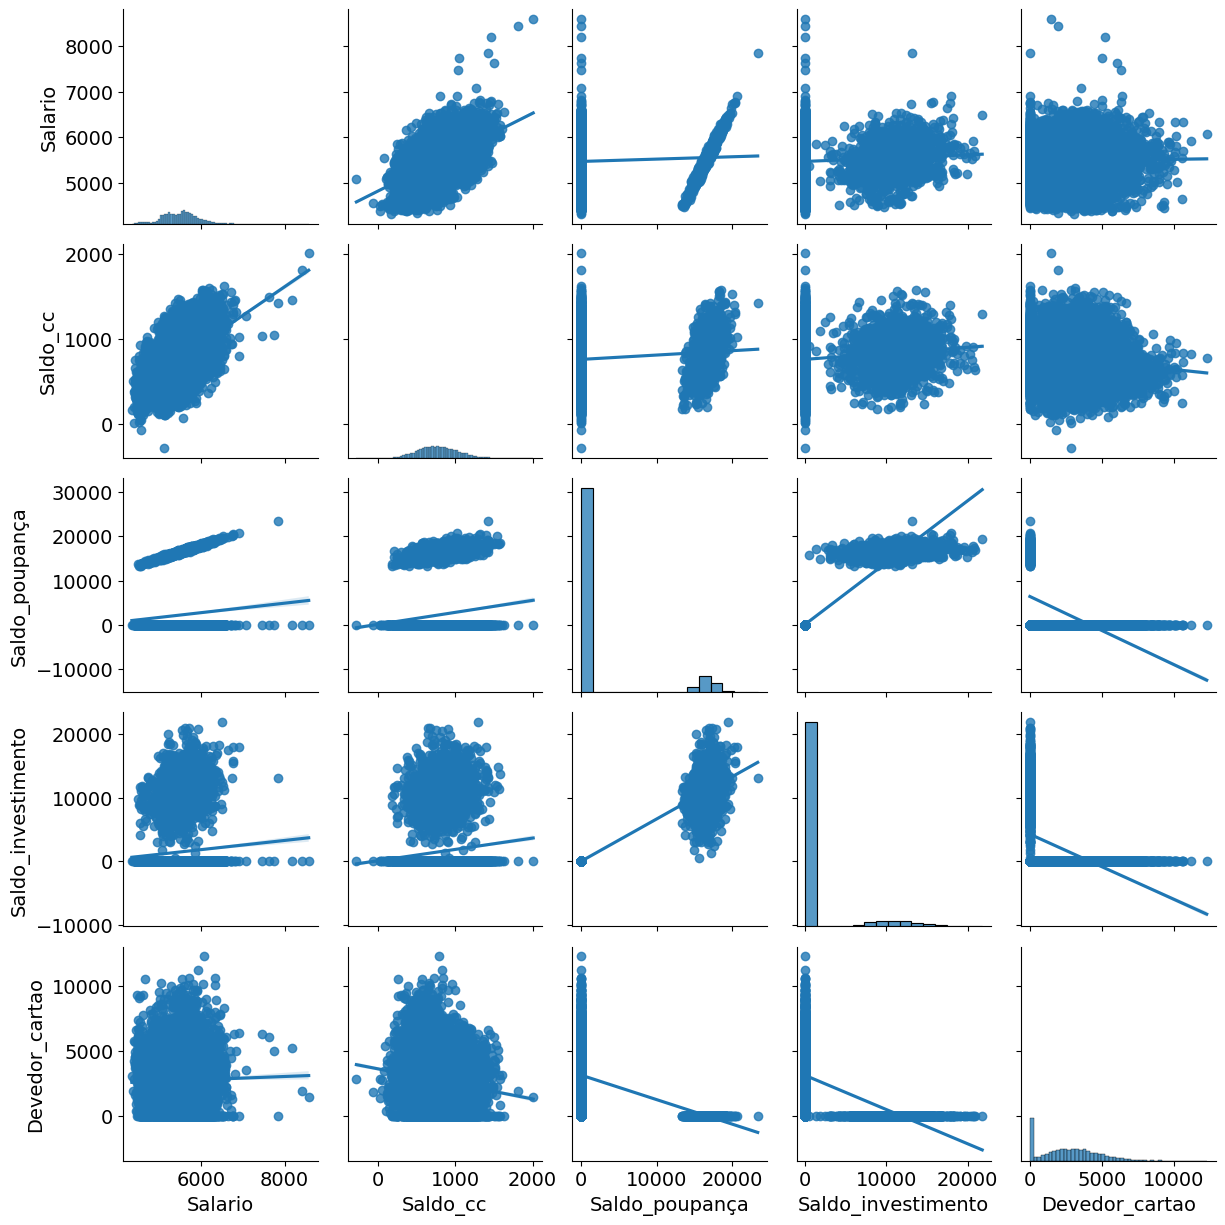

In [19]:
sns.pairplot(dados[['Salario','Saldo_cc','Saldo_poupança','Saldo_investimento','Devedor_cartao']], kind='reg')

In [20]:
dados = dados[dados['Devedor_cartao']!=0]
len(dados)

8323

In [21]:
#Divisão da base em treino e teste
dados_treino, dados_teste = train_test_split(dados, train_size=0.8, random_state=3)
dados['Devedor_cartao']

,Devedor_cartao
Cliente,
75928,6023.68
52921,1578.24
8387,2578.70
54522,4348.96
45397,1516.78
...,...
33487,1263.34
71360,5613.71
92455,1199.22


In [22]:
#Ajuste de MLG com resposta binária, iniciando com 4 preditoras
preditoras = dados_treino[['Salario','Devedor_cartao']]
resposta = dados_treino['Inadimplente']

preditoras.head()

,Salario,Devedor_cartao
Cliente,,
66105,5493.88,7421.83
20604,6220.00,711.69
80002,5090.00,2990.17
2762,5888.82,5848.05
47455,5696.74,3140.52


In [23]:
glm_binom = sm.GLM(resposta, preditoras, family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Inadimplente   No. Observations:                 6658
Model:                            GLM   Df Residuals:                     6656
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3490.4
Date:                Fri, 17 Jul 2026   Deviance:                       6980.9
Time:                        16:37:34   Pearson chi2:                 7.00e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1462
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Salario           -0.0005   1.39e-05    -36.

In [24]:
X_teste = dados_teste[['Salario','Devedor_cartao']]
y_teste = dados_teste['Inadimplente']

y_pred = res.predict(X_teste)

pred_1 = np.empty(len(res.predict(X_teste)))

for i in range(0, len(res.predict(X_teste)+1)):
  if (res.predict(X_teste).iloc[i]>0.5):
    pred_1[i] = 1

  else:
    pred_1[i] = 0

pred_1

array([0., 0., 0., ..., 1., 0., 0.])

In [25]:
print('Erro quadrático médio é: ', mean_squared_error(y_teste, pred_1))


Erro quadrático médio é:  0.24564564564564564


In [26]:
dados_treino.loc[:,'const'] = 1
dados_teste.loc[:,'const'] = 1

In [27]:
dados_treino.head()

,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente,const
Cliente,,,,,,,,,,
66105,M,34,Privada,5493.88,484.81,0.0,0.0,7421.83,1,1
20604,M,36,Privada,6220.00,662.72,0.0,0.0,711.69,0,1
80002,F,29,Privada,5090.00,906.09,0.0,0.0,2990.17,0,1
2762,M,35,Privada,5888.82,519.94,0.0,0.0,5848.05,1,1
47455,M,34,Privada,5696.74,796.16,0.0,0.0,3140.52,1,1


In [28]:
preditoras = dados_treino[['const','Salario','Devedor_cartao']]
resposta = dados_treino[['Inadimplente']]

X_teste = dados_teste[['const','Salario','Devedor_cartao']]
y_teste = dados_teste[['Inadimplente']]


In [30]:
glm_binom = sm.GLM(resposta, preditoras, family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           Inadimplente   No. Observations:                 6658
Model:                            GLM   Df Residuals:                     6655
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3461.8
Date:                Fri, 17 Jul 2026   Deviance:                       6923.5
Time:                        16:39:06   Pearson chi2:                 7.08e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1535
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.1571      0.420      7.

In [35]:
X_teste = dados_teste[['Salario','Devedor_cartao']]
y_teste = dados_teste['Inadimplente']

X_teste = sm.add_constant(X_teste)

y_predito = res.predict(X_teste)

predito_1 = np.empty(len(res.predict(X_teste)))

for i in range(0, len(res.predict(X_teste)+1)):
  if(res.predict(X_teste).iloc[i] > 0.5):
    predito_1[i] = 1

  else:
    predito_1[i] = 0

predito_1


array([0., 0., 0., ..., 1., 0., 0.])

In [36]:
print('Erro quadrático médio é: ',mean_squared_error(predito_1, y_teste))


Erro quadrático médio é:  0.24384384384384383


In [38]:
dados_treino.loc[:,'const'] = 1
dados_teste.loc[:,'const'] = 1

dados_treino.head()

,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente,const
Cliente,,,,,,,,,,
66105,M,34,Privada,5493.88,484.81,0.0,0.0,7421.83,1,1
20604,M,36,Privada,6220.00,662.72,0.0,0.0,711.69,0,1
80002,F,29,Privada,5090.00,906.09,0.0,0.0,2990.17,0,1
2762,M,35,Privada,5888.82,519.94,0.0,0.0,5848.05,1,1
47455,M,34,Privada,5696.74,796.16,0.0,0.0,3140.52,1,1


In [39]:
preditoras = dados_treino[['const','Salario','Devedor_cartao']]
resposta = dados_treino[['Inadimplente']]

X_teste = dados_teste[['const','Salario','Devedor_cartao']]
y_teste = dados_teste[['Inadimplente']]


In [40]:
glm_binom = sm.GLM(resposta, preditoras, family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())

predito = res.predict(X_teste)

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Inadimplente   No. Observations:                 6658
Model:                            GLM   Df Residuals:                     6655
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3461.8
Date:                Fri, 17 Jul 2026   Deviance:                       6923.5
Time:                        17:42:28   Pearson chi2:                 7.08e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1535
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.1571      0.420      7.

In [41]:
print("Erro quadrático médio = ", mean_squared_error(predito, y_teste))

Erro quadrático médio =  0.1775789230800455


In [42]:
predito_01 = np.empty(len(res.predict(X_teste)))

for i in range(0,len(res.predict(X_teste)+1)):
  if (res.predict(X_teste).iloc[i]>0.5):
    predito_01[i] = 1
  else:
    predito_01[i] = 0

#import confusion_matrix
from sklearn.metrics import confusion_matrix

y_predito = predito_01

confusion_matrix(y_teste,y_predito)

dados_teste['y_teste'] = dados_teste['Inadimplente']
dados_teste['y_predito'] = y_predito
dados_teste

,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente,const,y_teste,y_predito
Cliente,,,,,,,,,,,,
54342,M,34,Privada,5607.00,734.90,0.0,0.0,2801.94,0,1,0,0.0
76636,F,30,Privada,5429.00,766.01,0.0,0.0,3167.39,0,1,0,0.0
46875,F,35,Autônomo,5706.00,925.54,0.0,0.0,4749.06,0,1,0,0.0
73952,F,31,Autônomo,5173.00,820.84,0.0,0.0,2261.41,0,1,0,0.0
18722,M,35,Privada,5778.00,873.44,0.0,0.0,4023.62,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
70695,F,30,Pública,5218.00,606.57,0.0,0.0,2337.82,0,1,0,0.0
56036,M,28,Autônomo,4985.26,594.81,0.0,0.0,1360.51,1,1,1,0.0
73178,M,35,Privada,5586.98,904.94,0.0,0.0,5497.64,1,1,1,1.0


In [43]:
pd.crosstab(dados_teste['y_teste'], dados_teste['y_predito'], rownames=['True'], colnames=['Predicted'], margins=True)


Predicted,0.0,1.0,All
True,,,
0,1084,59,1143
1,347,175,522
All,1431,234,1665


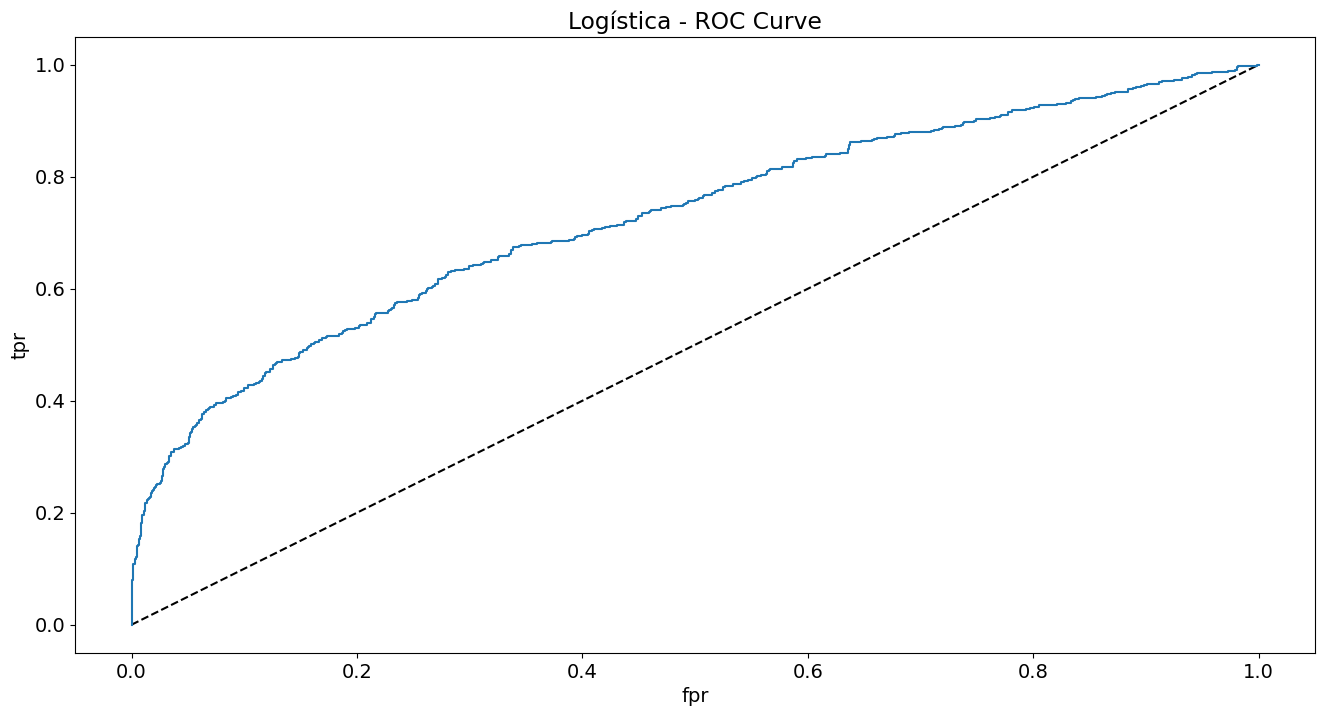

In [44]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_teste, predito)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, label='Logistica')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Logística - ROC Curve')
plt.show()

In [52]:
from sklearn.neighbors import KNeighborsClassifier

X_treino = dados_treino[['Salario','Devedor_cartao']].values
y_treino = dados_treino[['Inadimplente']].values

X_teste = dados_teste[['Salario','Devedor_cartao']].values
y_teste = dados_teste[['Inadimplente']].values



In [53]:
import sklearn as skl

scaler = skl.preprocessing.StandardScaler().fit(X_treino)
X_treino = scaler.transform(X_treino)
X_teste = scaler.transform(X_teste)

print(X_treino.shape)
print(y_treino.shape)

(6658, 2)
(6658, 1)


In [54]:
test_score = []
train_scores = []


for i in range(1,20):
  knn = KNeighborsClassifier(i)
  knn.fit(X_treino, y_treino)

  train_scores.append(knn.score(X_treino, y_treino))
  test_score.append(knn.score(X_teste, y_teste))


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

In [55]:
max_train_score = max(train_scores)
train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
print('Max train score {} % and k = {}'.format(max_train_score*100, list(map(lambda x: x+1, train_scores_ind))))

Max train score 100.0 % and k = [1]


In [58]:
max_test_score = max(test_score)
test_scores_ind = [i for i, v in enumerate(test_score) if v == max_test_score]
print('Max test score {} % and k = {}'.format(max_test_score*100, list(map(lambda x: x+1, test_scores_ind))))

Max test score 76.15615615615616 % and k = [13, 14]


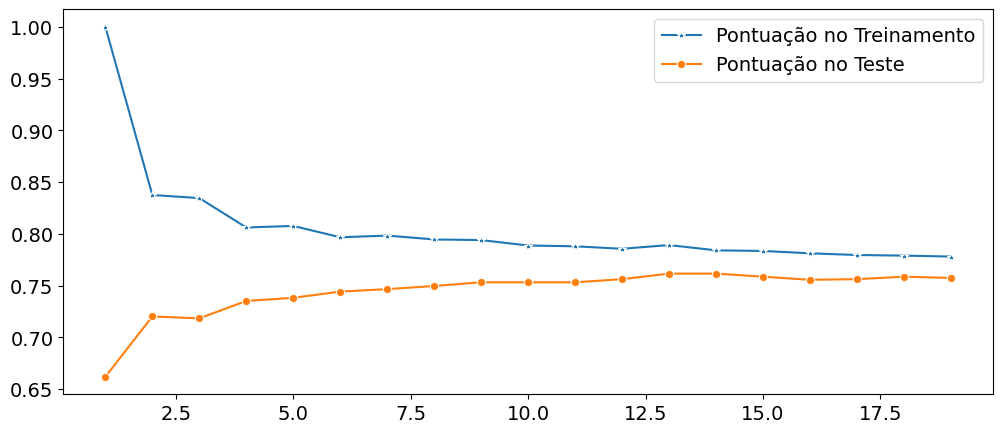

In [60]:
plt.figure(figsize=(12,5))
p = sns.lineplot(x=range(1,20), y=train_scores, marker='*', label='Pontuação no Treinamento')
p = sns.lineplot(x=range(1,20), y=test_score, marker='o', label='Pontuação no Teste')

In [61]:
#Para k = 14
knn = KNeighborsClassifier(14)

knn.fit(X_treino, y_treino)
knn.score(X_teste, y_teste)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.7615615615615615

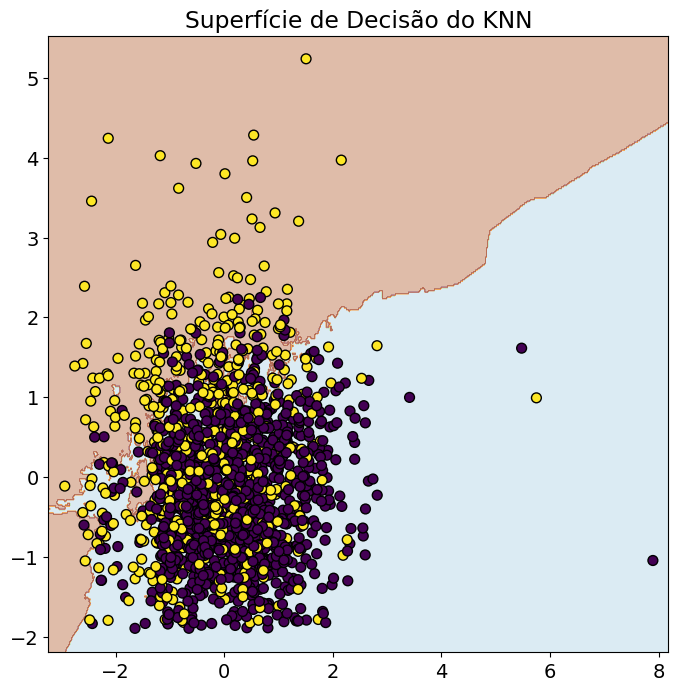

In [62]:
def plota_superficieDecisao(classifier, X, Y, ax, title =''):
  h = .02

  #Cria uma malha mesh
  x_min, x_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
  y_min, y_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

  #Obtém a predição
  Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])

  #Converte os valores do vetor para índices
  Z2 = np.unique(Z, return_inverse=True)[1]

  #Plota a superfície de decisão
  Z2 = Z2.reshape(xx.shape)
  ax.contourf(xx, yy, Z2, cmap=plt.cm.Paired, alpha=.4)

  #Converte os valores do vetor para índices
  Y2 = np.unique(Y, return_inverse=True)[1]

  #Plota os dados de treinamento
  ax.scatter(X[:,0], X[:, 1], c=Y2, edgecolors='k', s=50)

  ax.set_xlim(xx.min(), xx.max())
  ax.set_ylim(yy.min(), yy.max())
  ax.set_title(title, fontsize='large')

#Define o tamanho da figura:
fig, ax = plt.subplots(figsize=(8,8))

#Chama a função para plotar a superfície de decisão juntamente com os dados de teste
plota_superficieDecisao(knn, X_teste, y_teste, ax, title = "Superfície de Decisão do KNN")

